# ДЗ 2 — свёрточные сети

### Импорты


In [1]:
import copy
import json
import os
import random
from dataclasses import dataclass
from typing import Dict, List, Optional, Tuple

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

### Гиперпараметры и воспроизводимость

Функции блока:
- задаём число эпох и learning rate для всех сценариев;
- настраиваем `FREEZE_FIRST_BLOCKS` для эксперимента п.9;
- фиксируем `SEED` для повторяемых результатов.

In [2]:
SEED = 1216
EPOCHS = 10
LR = 1e-3
FREEZE_FIRST_BLOCKS = 1
DATA_DIR = "hw2/data"
OUT_DIR = "hw2/results"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 256 if device.type == "cuda" else 128
NUM_WORKERS = 2
PIN_MEMORY = device.type == "cuda"

os.makedirs(OUT_DIR, exist_ok=True)


def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


set_seed(SEED)


### Устройство (GPU / CPU)


In [22]:
if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))
    torch.backends.cudnn.benchmark = True


GPU: NVIDIA GeForce RTX 2060


## П. 1. Загрузка данных и подготовка

**Текст пункта из условия:** скачать `MNIST` и второй MNIST-подобный набор (`FashionMNIST`) и подготовить данные для обучения.

В этом блоке: загрузка `MNIST`/`FashionMNIST`, нормализация `x -> (x-0.5)/0.5`, создание `train/test` dataloader'ов.

In [4]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)),
])

mnist_train = datasets.MNIST(DATA_DIR, train=True, transform=transform, download=True)
mnist_test = datasets.MNIST(DATA_DIR, train=False, transform=transform, download=True)
fash_train = datasets.FashionMNIST(DATA_DIR, train=True, transform=transform, download=True)
fash_test = datasets.FashionMNIST(DATA_DIR, train=False, transform=transform, download=True)

loaders = {
    "mnist_train": DataLoader(mnist_train, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY),
    "mnist_test": DataLoader(mnist_test, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY),
    "fash_train": DataLoader(fash_train, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY),
    "fash_test": DataLoader(fash_test, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY),
}

criterion = nn.CrossEntropyLoss()

## П. 3. Архитектура CNN для MNIST

**Текст пункта из условия:** реализовать архитектуру свёрточной сети для классификации MNIST и выбрать эмпирический риск (рекомендуется cross-entropy).

В этом блоке:
- `SharedConvBackbone` извлекает признаки изображения;
- `MultiHeadCNN` добавляет две классификационные головы (`head1`, `head2`);
- для обучения используется `CrossEntropyLoss`.

In [5]:
class SharedConvBackbone(nn.Module):
    def __init__(self) -> None:
        super().__init__()
        self.block1 = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
        )
        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
        )
        self.block3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        return x

In [6]:
class MultiHeadCNN(nn.Module):
    def __init__(self, num_classes_head1: int, num_classes_head2: int) -> None:
        super().__init__()
        self.shared = SharedConvBackbone()
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.head1 = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.2),
            nn.Linear(128, num_classes_head1),
        )
        self.head2 = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.2),
            nn.Linear(128, num_classes_head2),
        )

    def extract(self, x: torch.Tensor) -> torch.Tensor:
        return self.pool(self.shared(x))

    def forward_head1(self, x: torch.Tensor) -> torch.Tensor:
        return self.head1(self.extract(x))

    def forward_head2(self, x: torch.Tensor) -> torch.Tensor:
        return self.head2(self.extract(x))

### Служебные функции: заморозка/инициализация слоёв

Функции блока:
- `freeze_module` включает/выключает обучение параметров (`requires_grad`);
- `randomize_module` случайно переинициализирует параметры;
- `freeze_first_conv_blocks` замораживает первые `N` свёрточных блоков для эксперимента п.9.

In [7]:
def freeze_module(module: nn.Module, freeze: bool) -> None:
    for parameter in module.parameters():
        parameter.requires_grad = not freeze


def randomize_module(module: nn.Module) -> None:
    for layer in module.modules():
        if isinstance(layer, (nn.Conv2d, nn.Linear)):
            nn.init.kaiming_normal_(layer.weight, nonlinearity="relu")
            if layer.bias is not None:
                nn.init.zeros_(layer.bias)
        elif isinstance(layer, nn.BatchNorm2d):
            nn.init.ones_(layer.weight)
            nn.init.zeros_(layer.bias)


def freeze_first_conv_blocks(backbone: SharedConvBackbone, num_blocks: int) -> None:
    blocks = [backbone.block1, backbone.block2, backbone.block3]
    for block_index, block in enumerate(blocks):
        freeze_module(block, freeze=(block_index < num_blocks))


@dataclass
class EpochMetrics:
    train_loss: float
    train_acc: float
    test_loss: float
    test_acc: float


def run_epoch(
    model: nn.Module,
    loader: DataLoader,
    criterion: nn.Module,
    optimizer: Optional[optim.Optimizer],
    device: torch.device,
    head: int,
    train: bool,
) -> Tuple[float, float]:
    model.train() if train else model.eval()
    total_loss, total_correct, total_count = 0.0, 0, 0
    non_blocking = device.type == "cuda"
    grad_context = torch.enable_grad() if train else torch.inference_mode()
    with grad_context:
        for batch_images, batch_labels in loader:
            batch_images = batch_images.to(device, non_blocking=non_blocking)
            batch_labels = batch_labels.to(device, non_blocking=non_blocking)
            if train and optimizer is not None:
                optimizer.zero_grad(set_to_none=True)
            logits = model.forward_head1(batch_images) if head == 1 else model.forward_head2(batch_images)
            loss = criterion(logits, batch_labels)
            if train and optimizer is not None:
                loss.backward()
                optimizer.step()

            predictions = logits.argmax(dim=1)
            total_correct += (predictions == batch_labels).sum().item()
            total_loss += loss.item() * batch_images.size(0)
            total_count += batch_images.size(0)

    return total_loss / max(total_count, 1), total_correct / max(total_count, 1)


def train_with_eval(
    model: nn.Module,
    train_loader: DataLoader,
    test_loader: DataLoader,
    criterion: nn.Module,
    optimizer: optim.Optimizer,
    device: torch.device,
    head: int,
    epochs: int,
) -> List[EpochMetrics]:
    history = []
    for _ in range(epochs):
        tr_loss, tr_acc = run_epoch(model, train_loader, criterion, optimizer, device, head=head, train=True)
        te_loss, te_acc = run_epoch(model, test_loader, criterion, optimizer=None, device=device, head=head, train=False)
        history.append(EpochMetrics(tr_loss, tr_acc, te_loss, te_acc))
    return history


def to_dict(history: List[EpochMetrics]) -> List[Dict[str, float]]:
    return [
        {
            "train_loss": epoch_metrics.train_loss,
            "train_acc": epoch_metrics.train_acc,
            "test_loss": epoch_metrics.test_loss,
            "test_acc": epoch_metrics.test_acc,
        }
        for epoch_metrics in history
    ]


### Служебные функции: dual-monitor для п.7 и п.8

Функции блока:
- `DualTaskEpochMetrics` хранит метрики сразу по двум задачам на эпоху;
- `train_head2_with_dual_curves` обучает вторую голову и параллельно мониторит первую задачу;
- `dual_history_to_*` преобразуют dual-историю в формат обычных кривых.

In [8]:
@dataclass
class DualTaskEpochMetrics:
    mnist_train_loss: float
    mnist_train_acc: float
    mnist_test_loss: float
    mnist_test_acc: float
    fashion_train_loss: float
    fashion_train_acc: float
    fashion_test_loss: float
    fashion_test_acc: float


def train_head2_one_epoch_eval_both(
    model: nn.Module,
    mnist_train_loader: DataLoader,
    mnist_test_loader: DataLoader,
    fash_train_loader: DataLoader,
    fash_test_loader: DataLoader,
    criterion: nn.Module,
    optimizer: optim.Optimizer,
    device: torch.device,
) -> DualTaskEpochMetrics:
    fashion_train_loss, fashion_train_acc = run_epoch(
        model, fash_train_loader, criterion, optimizer, device, head=2, train=True
    )
    mnist_train_loss, mnist_train_acc = run_epoch(
        model, mnist_train_loader, criterion, None, device, head=1, train=False
    )
    mnist_test_loss, mnist_test_acc = run_epoch(
        model, mnist_test_loader, criterion, None, device, head=1, train=False
    )
    fashion_test_loss, fashion_test_acc = run_epoch(
        model, fash_test_loader, criterion, None, device, head=2, train=False
    )
    return DualTaskEpochMetrics(
        mnist_train_loss,
        mnist_train_acc,
        mnist_test_loss,
        mnist_test_acc,
        fashion_train_loss,
        fashion_train_acc,
        fashion_test_loss,
        fashion_test_acc,
    )


def train_head2_with_dual_curves(
    model: nn.Module,
    mnist_train_loader: DataLoader,
    mnist_test_loader: DataLoader,
    fash_train_loader: DataLoader,
    fash_test_loader: DataLoader,
    criterion: nn.Module,
    optimizer: optim.Optimizer,
    device: torch.device,
    epochs: int,
) -> List[DualTaskEpochMetrics]:
    dual_history = []
    for _ in range(epochs):
        dual_history.append(
            train_head2_one_epoch_eval_both(
                model,
                mnist_train_loader,
                mnist_test_loader,
                fash_train_loader,
                fash_test_loader,
                criterion,
                optimizer,
                device,
            )
        )
    return dual_history


def dual_history_to_mnist_metrics(dual_history: List[DualTaskEpochMetrics]) -> List[EpochMetrics]:
    return [
        EpochMetrics(item.mnist_train_loss, item.mnist_train_acc, item.mnist_test_loss, item.mnist_test_acc)
        for item in dual_history
    ]


def dual_history_to_fashion_metrics(dual_history: List[DualTaskEpochMetrics]) -> List[EpochMetrics]:
    return [
        EpochMetrics(
            item.fashion_train_loss,
            item.fashion_train_acc,
            item.fashion_test_loss,
            item.fashion_test_acc,
        )
        for item in dual_history
    ]

## П. 4. Обучение архитектуры на MNIST и кривые train/test

Функция блока (п.4): обучаем `head1` на `MNIST`, сохраняем историю `train/test` для построения кривых обучения.

In [9]:
all_histories = {}

model = MultiHeadCNN(num_classes_head1=10, num_classes_head2=10).to(device)
opt_a = optim.Adam(model.parameters(), lr=LR)
hist_a = train_with_eval(
    model,
    loaders["mnist_train"],
    loaders["mnist_test"],
    criterion,
    opt_a,
    device,
    head=1,
    epochs=EPOCHS,
)
all_histories["A_mnist_head1"] = hist_a

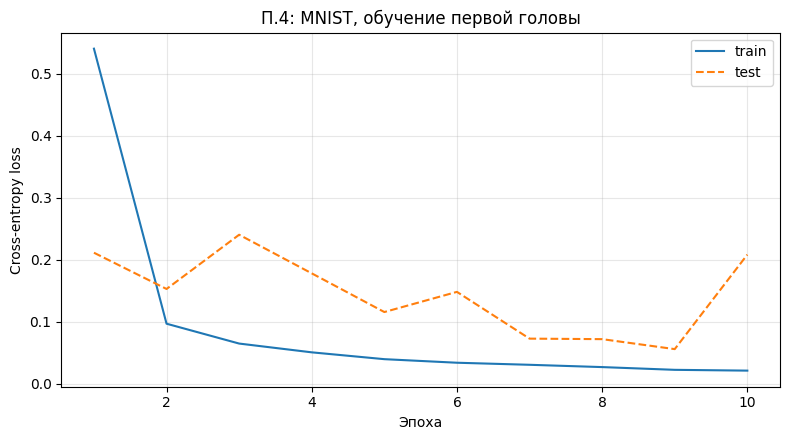

In [10]:
epochs_axis = np.arange(1, len(hist_a) + 1)
plt.figure(figsize=(8, 4.5))
plt.plot(epochs_axis, [item.train_loss for item in hist_a], label="train")
plt.plot(epochs_axis, [item.test_loss for item in hist_a], linestyle="--", label="test")
plt.title("П.4: MNIST, обучение первой головы")
plt.xlabel("Эпоха")
plt.ylabel("Cross-entropy loss")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## П. 5. Добавление второй головы и сохранение параметров

**Текст пункта из условия:** добавить новую голову и сохранить параметры общих свёрточных слоёв, первой и ещё не обученной второй головы.

В этом блоке: фиксируем состояние всей модели (`shared`, `head1`, `head2`) в чекпоинт после сценария A.

In [11]:
ckpt_path = os.path.join(OUT_DIR, "stageA_after_mnist.pt")
torch.save(model.state_dict(), ckpt_path)

## П. 6. Обучение второй головы при замороженном `shared`

**Текст пункта из условия:** обучить вторую голову для второго датасета при замороженных общих свёрточных преобразованиях и построить кривые второй задачи.

В этом блоке: обучается `head2` на `FashionMNIST`, при этом `shared` и `head1` заморожены.

In [12]:
model_b = copy.deepcopy(model)
freeze_module(model_b.shared, freeze=True)
freeze_module(model_b.head1, freeze=True)
freeze_module(model_b.head2, freeze=False)
opt_b = optim.Adam(filter(lambda p: p.requires_grad, model_b.parameters()), lr=LR)
hist_b = train_with_eval(
    model_b,
    loaders["fash_train"],
    loaders["fash_test"],
    criterion,
    opt_b,
    device,
    head=2,
    epochs=EPOCHS,
)
all_histories["B_head2_frozen_backbone"] = hist_b
state_after_B = copy.deepcopy(model_b.state_dict())

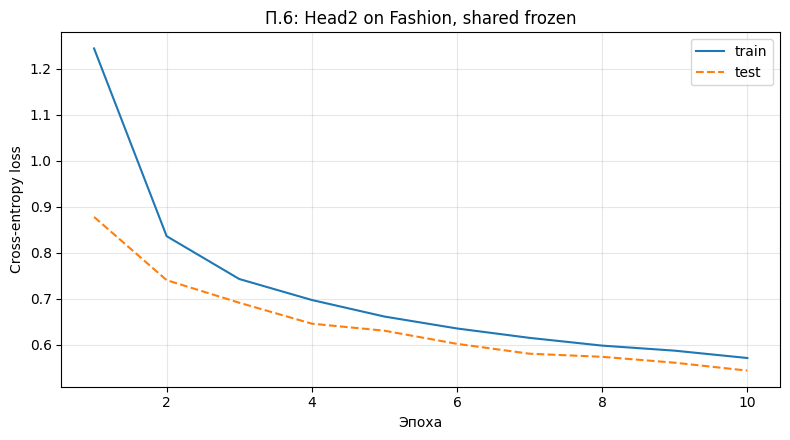

In [13]:
epochs_axis = np.arange(1, len(hist_b) + 1)
plt.figure(figsize=(8, 4.5))
plt.plot(epochs_axis, [item.train_loss for item in hist_b], label="train")
plt.plot(epochs_axis, [item.test_loss for item in hist_b], linestyle="--", label="test")
plt.title("П.6: Head2 on Fashion, shared frozen")
plt.xlabel("Эпоха")
plt.ylabel("Cross-entropy loss")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## П. 7. Разморозка `shared` и дообучение второй головы

**Текст пункта из условия:** разморозить общие свёрточные преобразования, дообучить вторую голову и построить кривые для первой и второй задачи.

В этом блоке: размораживаем `shared`, дообучаем вторую задачу и параллельно мониторим кривые первой.

In [14]:
freeze_module(model_b.shared, freeze=False)
opt_c = optim.Adam(filter(lambda p: p.requires_grad, model_b.parameters()), lr=LR * 0.5)
hist_c_dual = train_head2_with_dual_curves(
    model_b,
    loaders["mnist_train"],
    loaders["mnist_test"],
    loaders["fash_train"],
    loaders["fash_test"],
    criterion,
    opt_c,
    device,
    EPOCHS,
)
hist_c_fashion = dual_history_to_fashion_metrics(hist_c_dual)
hist_c_mnist = dual_history_to_mnist_metrics(hist_c_dual)
all_histories["C_fashion_head2"] = hist_c_fashion
all_histories["C_mnist_head1_monitor"] = hist_c_mnist
state_after_C = copy.deepcopy(model_b.state_dict())

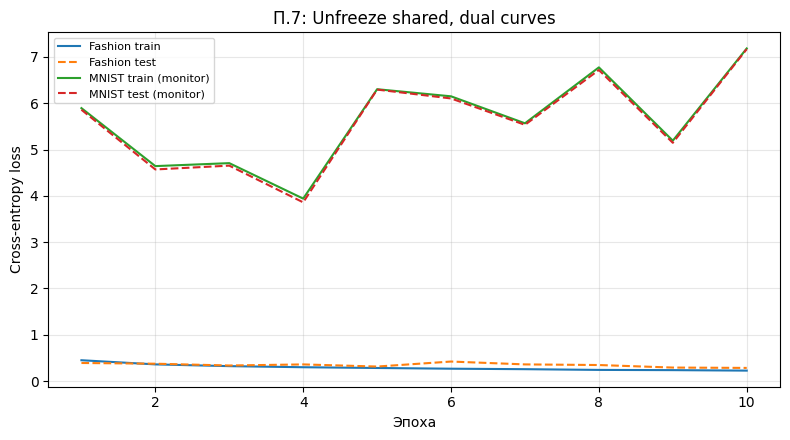

In [15]:
epochs_axis = np.arange(1, len(hist_c_fashion) + 1)
plt.figure(figsize=(8, 4.5))
plt.plot(epochs_axis, [item.train_loss for item in hist_c_fashion], label="Fashion train")
plt.plot(epochs_axis, [item.test_loss for item in hist_c_fashion], linestyle="--", label="Fashion test")
plt.plot(epochs_axis, [item.train_loss for item in hist_c_mnist], label="MNIST train (monitor)")
plt.plot(epochs_axis, [item.test_loss for item in hist_c_mnist], linestyle="--", label="MNIST test (monitor)")
plt.title("П.7: Unfreeze shared, dual curves")
plt.xlabel("Эпоха")
plt.ylabel("Cross-entropy loss")
plt.grid(alpha=0.3)
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

## П. 8. Загрузка чекпоинта и обучение с разморозкой сразу

Функция блока (п.8): загружаем сохранённые параметры после `A`, затем обучаем вторую задачу при сразу размороженном `shared` с мониторингом первой задачи.

In [16]:
model_d = MultiHeadCNN(num_classes_head1=10, num_classes_head2=10).to(device)
model_d.load_state_dict(torch.load(ckpt_path, map_location=device))
freeze_module(model_d.head1, freeze=True)
freeze_module(model_d.head2, freeze=False)
freeze_module(model_d.shared, freeze=False)
opt_d = optim.Adam(filter(lambda p: p.requires_grad, model_d.parameters()), lr=LR * 0.5)
hist_d_dual = train_head2_with_dual_curves(
    model_d,
    loaders["mnist_train"],
    loaders["mnist_test"],
    loaders["fash_train"],
    loaders["fash_test"],
    criterion,
    opt_d,
    device,
    EPOCHS,
)
hist_d_fashion = dual_history_to_fashion_metrics(hist_d_dual)
hist_d_mnist = dual_history_to_mnist_metrics(hist_d_dual)
all_histories["D_fashion_head2"] = hist_d_fashion
all_histories["D_mnist_head1_monitor"] = hist_d_mnist
state_after_D = copy.deepcopy(model_d.state_dict())

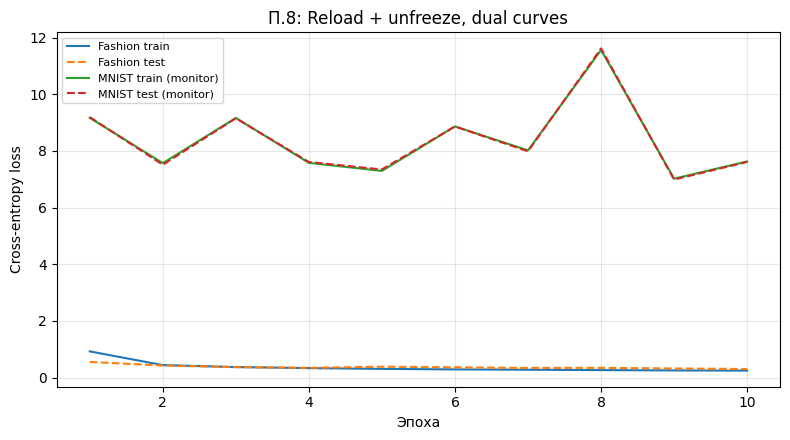

In [17]:
epochs_axis = np.arange(1, len(hist_d_fashion) + 1)
plt.figure(figsize=(8, 4.5))
plt.plot(epochs_axis, [item.train_loss for item in hist_d_fashion], label="Fashion train")
plt.plot(epochs_axis, [item.test_loss for item in hist_d_fashion], linestyle="--", label="Fashion test")
plt.plot(epochs_axis, [item.train_loss for item in hist_d_mnist], label="MNIST train (monitor)")
plt.plot(epochs_axis, [item.test_loss for item in hist_d_mnist], linestyle="--", label="MNIST test (monitor)")
plt.title("П.8: Reload + unfreeze, dual curves")
plt.xlabel("Эпоха")
plt.ylabel("Cross-entropy loss")
plt.grid(alpha=0.3)
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

## П. 9. Случайная инициализация и заморозка начальных блоков

**Текст пункта из условия:** заполнить параметры случайно, заморозить несколько начальных свёрточных слоёв и обучить оставшиеся слои для второй задачи.

В этом блоке: используем random init, замораживаем первые `FREEZE_FIRST_BLOCKS` блока и обучаем модель на второй задаче.

In [18]:
model_e = MultiHeadCNN(num_classes_head1=10, num_classes_head2=10).to(device)
randomize_module(model_e)
freeze_first_conv_blocks(model_e.shared, FREEZE_FIRST_BLOCKS)
freeze_module(model_e.head1, freeze=True)
freeze_module(model_e.head2, freeze=False)
opt_e = optim.Adam(filter(lambda p: p.requires_grad, model_e.parameters()), lr=LR)
hist_e = train_with_eval(
    model_e,
    loaders["fash_train"],
    loaders["fash_test"],
    criterion,
    opt_e,
    device,
    head=2,
    epochs=EPOCHS,
)
all_histories["E_random_init_partial_freeze"] = hist_e
state_after_E = copy.deepcopy(model_e.state_dict())

candidates = [
    ("B", hist_b[-1].test_acc, state_after_B),
    ("C", hist_c_fashion[-1].test_acc, state_after_C),
    ("D", hist_d_fashion[-1].test_acc, state_after_D),
    ("E", hist_e[-1].test_acc, state_after_E),
]
best_name, best_acc, best_state = max(candidates, key=lambda item: item[1])
model_best = MultiHeadCNN(num_classes_head1=10, num_classes_head2=10).to(device)
model_best.load_state_dict(best_state)
_ = model_best.eval()

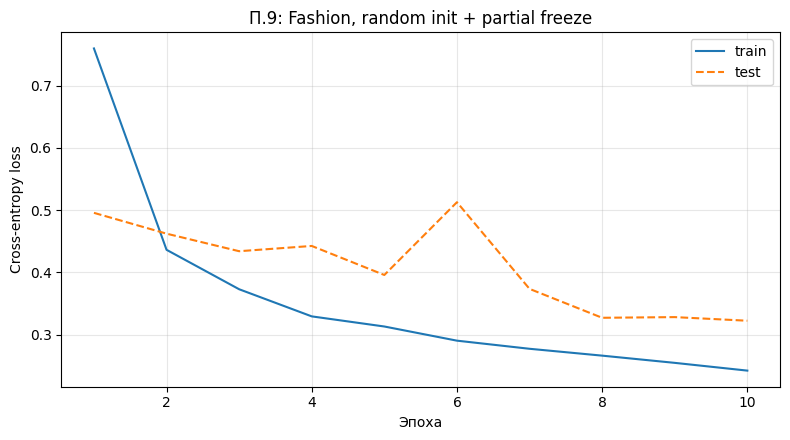

In [19]:
epochs_axis = np.arange(1, len(hist_e) + 1)
plt.figure(figsize=(8, 4.5))
plt.plot(epochs_axis, [item.train_loss for item in hist_e], label="train")
plt.plot(epochs_axis, [item.test_loss for item in hist_e], linestyle="--", label="test")
plt.title("П.9: Fashion, random init + partial freeze")
plt.xlabel("Эпоха")
plt.ylabel("Cross-entropy loss")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## П. 10. Все кривые обучения на одном графике

В этом блоке: строим объединённый график `train/test cross-entropy` для всех сценариев A-E и сохраняем его в `all_learning_curves.png`.

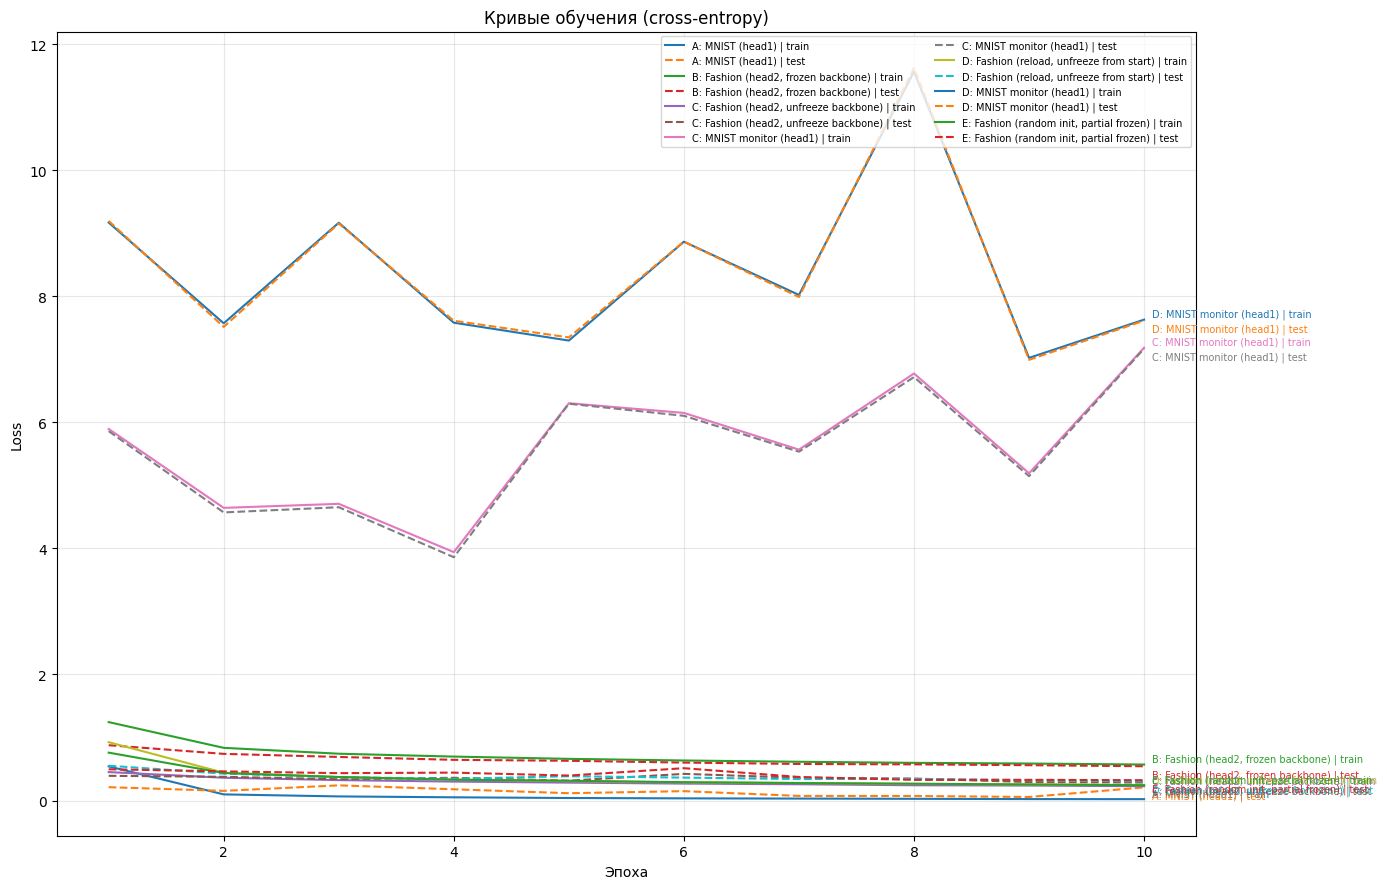

In [20]:
name_map = {
    "A_mnist_head1": "A: MNIST (head1)",
    "B_head2_frozen_backbone": "B: Fashion (head2, frozen backbone)",
    "C_fashion_head2": "C: Fashion (head2, unfreeze backbone)",
    "C_mnist_head1_monitor": "C: MNIST monitor (head1)",
    "D_fashion_head2": "D: Fashion (reload, unfreeze from start)",
    "D_mnist_head1_monitor": "D: MNIST monitor (head1)",
    "E_random_init_partial_freeze": "E: Fashion (random init, partial frozen)",
}

plt.figure(figsize=(14, 9))
for label, hist in all_histories.items():
    xs = np.arange(1, len(hist) + 1)
    train_losses = [item.train_loss for item in hist]
    test_losses = [item.test_loss for item in hist]
    pretty = name_map.get(label, label)

    train_line, = plt.plot(xs, train_losses, label=f"{pretty} | train")
    test_line, = plt.plot(xs, test_losses, linestyle="--", label=f"{pretty} | test")

    plt.annotate(
        f"{pretty} | train",
        xy=(xs[-1], train_losses[-1]),
        xytext=(6, 2),
        textcoords="offset points",
        color=train_line.get_color(),
        fontsize=7,
    )
    plt.annotate(
        f"{pretty} | test",
        xy=(xs[-1], test_losses[-1]),
        xytext=(6, -8),
        textcoords="offset points",
        color=test_line.get_color(),
        fontsize=7,
    )

plt.title("Кривые обучения (cross-entropy)")
plt.xlabel("Эпоха")
plt.ylabel("Loss")
plt.grid(alpha=0.3)
plt.legend(fontsize=7, ncol=2, loc="upper right")
plt.tight_layout()
curves_path = os.path.join(OUT_DIR, "all_learning_curves.png")
plt.savefig(curves_path, dpi=160)
plt.show()

with open(os.path.join(OUT_DIR, "histories.json"), "w", encoding="utf-8") as file_obj:
    json.dump({key: to_dict(value) for key, value in all_histories.items()}, file_obj, ensure_ascii=False, indent=2)


## П. 11. Самые похожие изображения между парами классов

В этом блоке: для каждой пары `(c, t)` выбираем пример класса `c` с максимальной вероятностью `p(t|x) = softmax(logits)_t` и сохраняем результаты в `fashion_similarity_pair_grid.png` и `pair_report.json`.

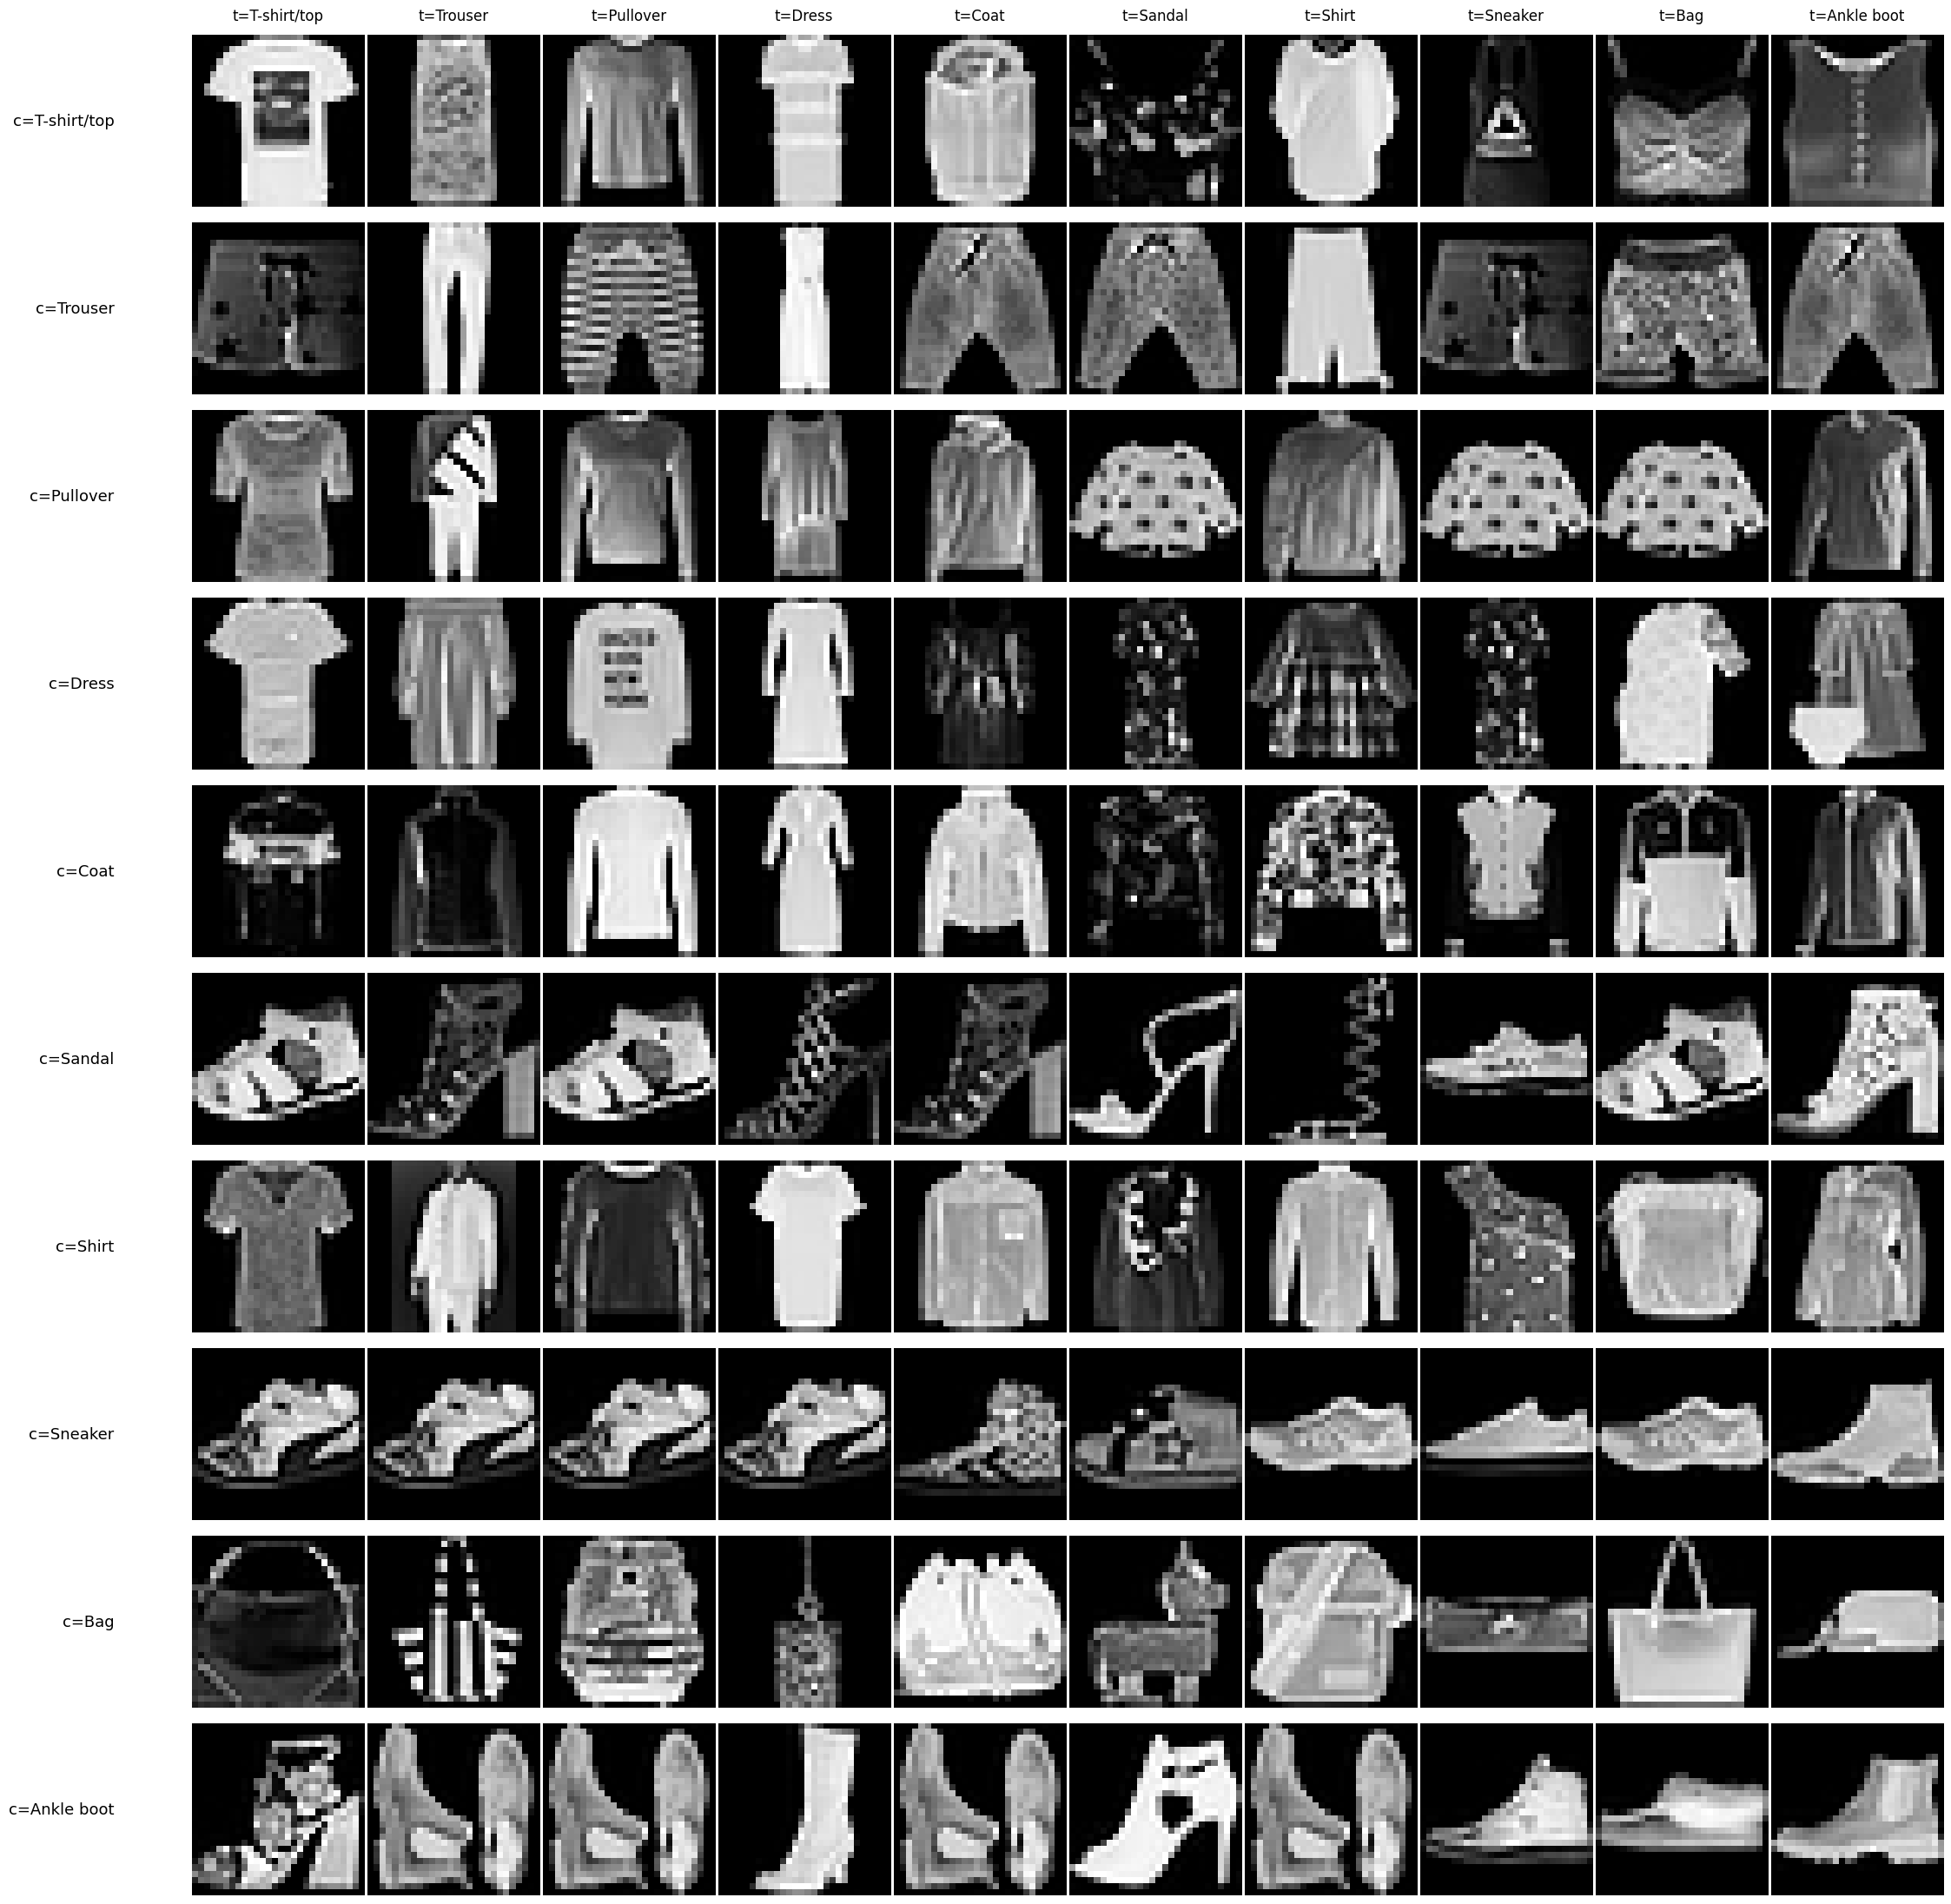

A test_acc (MNIST): 0.9358
B test_acc (Fashion): 0.8032
C test_acc (Fashion): 0.8984
D test_acc (Fashion): 0.8937
E test_acc (Fashion): 0.8826
Лучшая модель для второй задачи: C (fashion_test_acc=0.8984)


In [21]:
class_names_fashion = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

best = {}
with torch.no_grad():
    for batch_images, batch_labels in loaders["fash_test"]:
        batch_images = batch_images.to(device)
        batch_labels = batch_labels.to(device)
        probs = torch.softmax(model_best.forward_head2(batch_images), dim=1)
        for sample_idx in range(batch_images.size(0)):
            true_class = int(batch_labels[sample_idx].item())
            for target_class in range(10):
                score = float(probs[sample_idx, target_class].item())
                key = (true_class, target_class)
                if key not in best or score > best[key][0]:
                    best[key] = (score, batch_images[sample_idx].detach().cpu())

fig, axes = plt.subplots(10, 10, figsize=(28, 28))
pair_report = {}
for source_class in range(10):
    row_name = class_names_fashion[source_class]
    pair_report[row_name] = {}
    for target_class in range(10):
        prob, img = best[(source_class, target_class)]
        pair_report[row_name][class_names_fashion[target_class]] = prob
        axis = axes[source_class, target_class]
        axis.imshow(img.squeeze(0), cmap="gray")
        axis.axis("off")
        if source_class == 0:
            axis.set_title(f"t={class_names_fashion[target_class]}", fontsize=12, pad=12)

    axes[source_class, 0].text(
        -0.45,
        0.5,
        f"c={class_names_fashion[source_class]}",
        transform=axes[source_class, 0].transAxes,
        fontsize=13,
        va="center",
        ha="right",
    )

plt.subplots_adjust(left=0.18, wspace=0.02, hspace=0.02)
pair_grid_path = os.path.join(OUT_DIR, "fashion_similarity_pair_grid.png")
plt.savefig(pair_grid_path, dpi=300, bbox_inches="tight")
plt.show()

with open(os.path.join(OUT_DIR, "pair_report.json"), "w", encoding="utf-8") as f:
    json.dump(pair_report, f, ensure_ascii=False, indent=2)

metrics_summary = {
    "A_final": to_dict(hist_a)[-1],
    "B_final": to_dict(hist_b)[-1],
    "C_final_fashion": to_dict(hist_c_fashion)[-1],
    "C_final_mnist_monitor": to_dict(hist_c_mnist)[-1],
    "D_final_fashion": to_dict(hist_d_fashion)[-1],
    "D_final_mnist_monitor": to_dict(hist_d_mnist)[-1],
    "E_final": to_dict(hist_e)[-1],
    "best_for_task2": {"name": best_name, "fashion_test_acc": float(best_acc)},
}
with open(os.path.join(OUT_DIR, "metrics.json"), "w", encoding="utf-8") as f:
    json.dump(metrics_summary, f, ensure_ascii=False, indent=2)

print(f"A test_acc (MNIST): {metrics_summary['A_final']['test_acc']:.4f}")
print(f"B test_acc (Fashion): {metrics_summary['B_final']['test_acc']:.4f}")
print(f"C test_acc (Fashion): {metrics_summary['C_final_fashion']['test_acc']:.4f}")
print(f"D test_acc (Fashion): {metrics_summary['D_final_fashion']['test_acc']:.4f}")
print(f"E test_acc (Fashion): {metrics_summary['E_final']['test_acc']:.4f}")
print(f"Лучшая модель для второй задачи: {best_name} (fashion_test_acc={best_acc:.4f})")
